In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
n = 1500
x = np.random.uniform(-10 , 20 , n)
true_intercept = 5.0
true_slope = 2.5
noise_sd = 1.6
y_true = true_intercept + true_slope * x
y = y_true + np.random.normal(0 , noise_sd , n)

def design_matrix(x_vals: np.ndarray , degree: int) -> np.ndarray:
    cols = [np.ones_like(x_vals)]
    for d in range(1 , degree + 1):
        cols.append(x_vals ** d)
    return np.column_stack(cols)

DEGREE = 1

X = design_matrix(x , DEGREE)

In [3]:
beta_hat , *_ = np.linalg.lstsq(X , y , rcond = None)
y_hat = X @ beta_hat
resid = y - y_hat
mse = np.mean(resid ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(resid))
ss_tot = np.sum((y - np.mean(y)) ** 2)
ss_res = np.sum((y - y_hat) ** 2)
r2 = 1 - ss_res / ss_tot

x_grid = np.linspace(x.min() , x.max() , 300)
Xg = design_matrix(x_grid , DEGREE)
y_grid_hat = Xg @ beta_hat
y_grid_true = true_intercept + true_slope * x_grid

Text(0.5, 1.0, 'OLS Fit (Baseline)')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

Text(0.03, 0.97, 'OLS slope ≈ 2.506\nOLS intercept ≈ 5.019\nR² ≈ 0.995\nRMSE ≈ 1.577')

Text(0.5, 1.0, 'Residuals vs X (Diagnostic)')

...

(array([  7.,  11.,  23.,  56., 100., 150., 206., 240., 220., 197., 133.,
         77.,  47.,  18.,  10.,   5.]),
 array([-4.86258715, -4.24240879, -3.62223042, -3.00205206, -2.38187369,
        -1.76169532, -1.14151696, -0.52133859,  0.09883978,  0.71901814,
         1.33919651,  1.95937488,  2.57955324,  3.19973161,  3.81990998,
         4.44008834,  5.06026671]),
 <BarContainer object of 16 artists>)

Text(0.5, 1.0, 'Residual Histogram')

Text(0.5, 0, 'Residual')

Text(0, 0.5, 'Count')

Text(0.5, 1.02, 'Least Squares Linear Regression: A Clean Baseline')

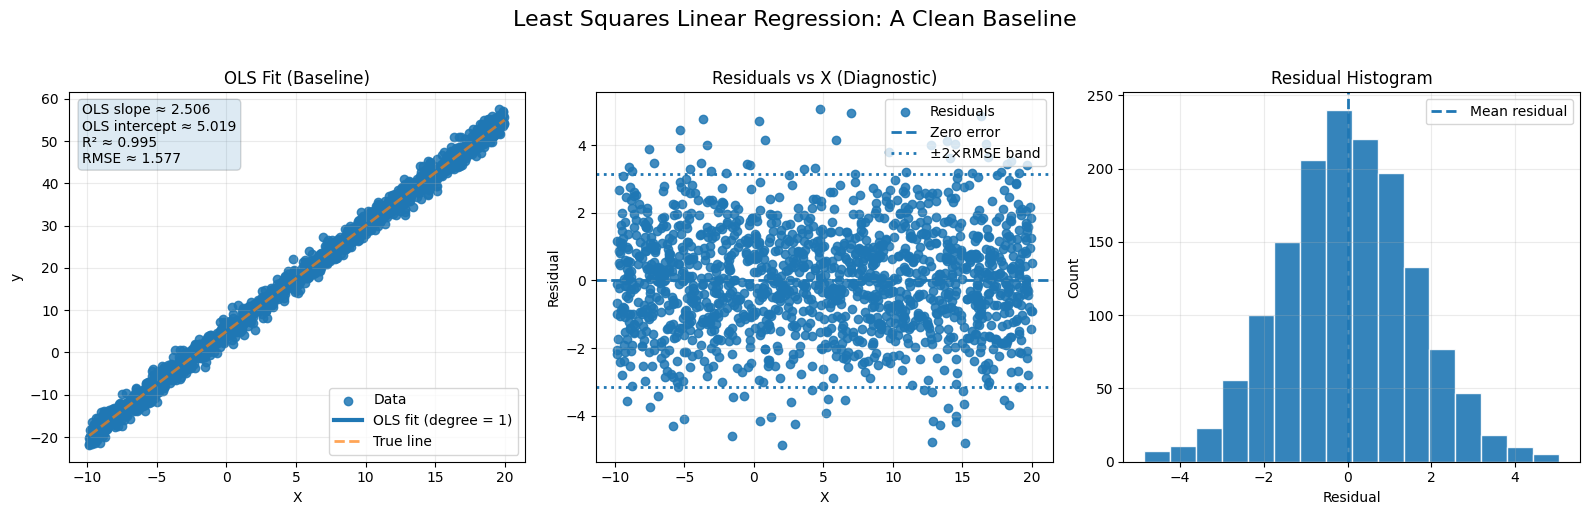

In [4]:
fig , axes = plt.subplots(1 , 3 , figsize = (16 , 5))

ax = axes[0]
ax.scatter(x , y , alpha = 0.85 , label = "Data")
ax.plot(x_grid , y_grid_hat , linewidth = 3 , label = f"OLS fit (degree = {DEGREE})")
ax.plot(x_grid , y_grid_true , linewidth = 2 , linestyle = "--" , alpha = 0.7 , label = "True line")
ax.set_title("OLS Fit (Baseline)")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.grid(True , alpha = 0.25)
ax.legend(loc = "lower right")
stats_text = (
    f"OLS slope ≈ {beta_hat[1]:.3f}\n"
    f"OLS intercept ≈ {beta_hat[0]:.3f}\n"
    f"R² ≈ {r2:.3f}\n"
    f"RMSE ≈ {rmse:.3f}"
)
ax.text(
    0.03 , 0.97 , stats_text , transform = ax.transAxes ,
    va = "top" , bbox = dict(boxstyle = "round" , alpha = 0.15)
)

ax = axes[1]
ax.scatter(x , resid , alpha = 0.85 , label = "Residuals")
ax.axhline(0 , linestyle = "--" , linewidth = 2 , label = "Zero error")
band = 2 * rmse
ax.axhline(+band , linestyle = ":" , linewidth = 2 , label = "±2×RMSE band")
ax.axhline(-band , linestyle = ":" , linewidth = 2)
ax.set_title("Residuals vs X (Diagnostic)")
ax.set_xlabel("X")
ax.set_ylabel("Residual")
ax.grid(True , alpha = 0.25)
ax.legend(loc = "upper right")

ax = axes[2]
ax.hist(resid , bins = 16 , edgecolor = "white" , alpha = 0.9)
ax.axvline(np.mean(resid) , linestyle = "--" , linewidth = 2 , label = "Mean residual")
ax.set_title("Residual Histogram")
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.grid(True , alpha = 0.25)
ax.legend(loc = "upper right")

fig.suptitle("Least Squares Linear Regression: A Clean Baseline" , fontsize = 16 , y = 1.02)
fig.tight_layout()
plt.show()

In [5]:
print("=== OLS Baseline Summary ===")
print(f"degree = {DEGREE}")
print(f"beta_hat = {beta_hat}")
print(f"R^2 = {r2:.3f} , RMSE = {rmse:.3f} , MAE = {mae:.3f}")

=== OLS Baseline Summary ===
degree = 1
beta_hat = [5.01864127 2.50629121]
R^2 = 0.995 , RMSE = 1.577 , MAE = 1.257


In [6]:
np.random.seed(42)
n = 1500
x = np.random.uniform(-25 , 25 , n)
true_intercept = 5.0
true_slope1 = 2.5
true_slope2 = 5.2
true_slope3 = 5.8
true_slope4 = 9.5
true_slope5 = -4.9
noise_sd = 1.6
y_true = true_intercept + true_slope1 * x + true_slope2 * (x ** 2) + true_slope3 * (x ** 3) + true_slope4 * (x ** 4) + true_slope5 * (x ** 5)
y = y_true + np.random.normal(0 , noise_sd , n)

DEGREE = 5

In [7]:
X = design_matrix(x , DEGREE)

beta_hat , *_ = np.linalg.lstsq(X , y , rcond = None)
y_hat = X @ beta_hat
resid = y - y_hat
mse = np.mean(resid ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(resid))
ss_tot = np.sum((y - np.mean(y)) ** 2)
ss_res = np.sum((y - y_hat) ** 2)
r2 = 1 - ss_res / ss_tot

x_grid = np.linspace(x.min() , x.max() , 300)
Xg = design_matrix(x_grid , DEGREE)
y_grid_hat = Xg @ beta_hat
y_grid_true = true_intercept + true_slope * x_grid

Text(0.5, 1.0, 'OLS Fit (Baseline)')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

Text(0.03, 0.97, 'OLS slope ≈ 2.512\nOLS intercept ≈ 5.052\nR² ≈ 1.000\nRMSE ≈ 1.577')

Text(0.5, 1.0, 'Residuals vs X (Diagnostic)')

...

(array([  7.,  10.,  25.,  54., 105., 159., 195., 245., 219., 190., 141.,
         73.,  43.,  19.,  10.,   5.]),
 array([-4.8285583 , -4.21043973, -3.59232115, -2.97420257, -2.356084  ,
        -1.73796542, -1.11984684, -0.50172827,  0.11639031,  0.73450889,
         1.35262746,  1.97074604,  2.58886461,  3.20698319,  3.82510177,
         4.44322034,  5.06133892]),
 <BarContainer object of 16 artists>)

Text(0.5, 1.0, 'Residual Histogram')

Text(0.5, 0, 'Residual')

Text(0, 0.5, 'Count')

Text(0.5, 1.02, 'Least Squares Linear Regression: A Clean Baseline')

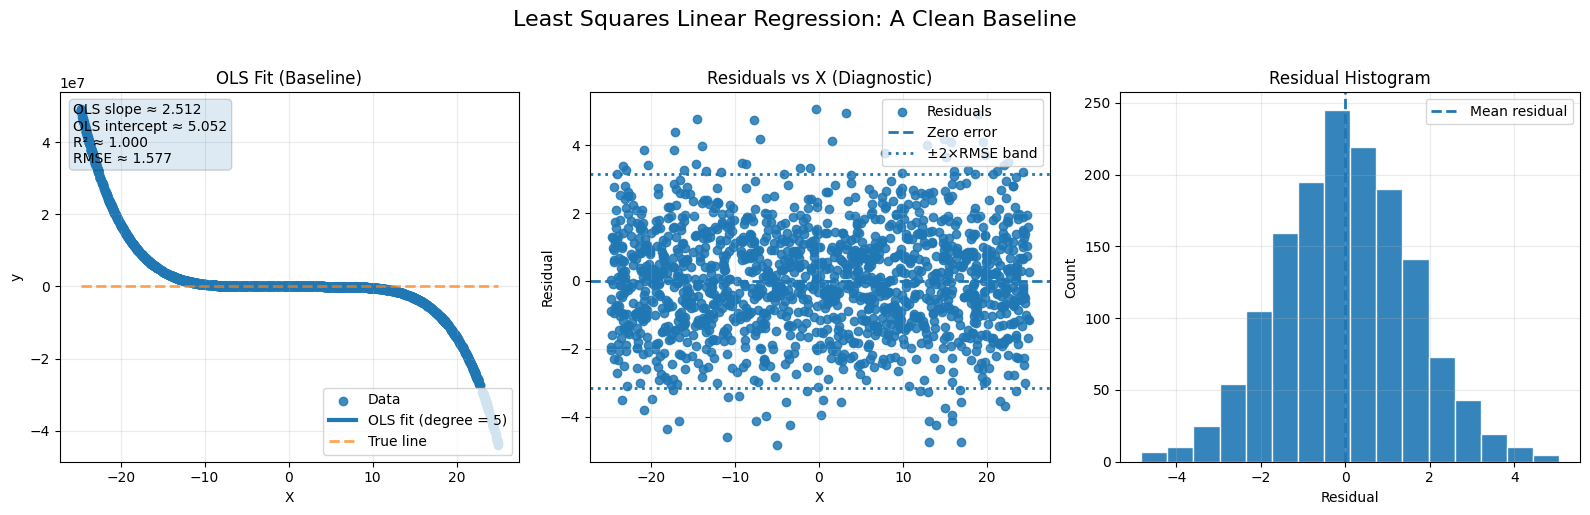

In [8]:
fig , axes = plt.subplots(1 , 3 , figsize = (16 , 5))

ax = axes[0]
ax.scatter(x , y , alpha = 0.85 , label = "Data")
ax.plot(x_grid , y_grid_hat , linewidth = 3 , label = f"OLS fit (degree = {DEGREE})")
ax.plot(x_grid , y_grid_true , linewidth = 2 , linestyle = "--" , alpha = 0.7 , label = "True line")
ax.set_title("OLS Fit (Baseline)")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.grid(True , alpha = 0.25)
ax.legend(loc = "lower right")
stats_text = (
    f"OLS slope ≈ {beta_hat[1]:.3f}\n"
    f"OLS intercept ≈ {beta_hat[0]:.3f}\n"
    f"R² ≈ {r2:.3f}\n"
    f"RMSE ≈ {rmse:.3f}"
)
ax.text(
    0.03 , 0.97 , stats_text , transform = ax.transAxes ,
    va = "top" , bbox = dict(boxstyle = "round" , alpha = 0.15)
)

ax = axes[1]
ax.scatter(x , resid , alpha = 0.85 , label = "Residuals")
ax.axhline(0 , linestyle = "--" , linewidth = 2 , label = "Zero error")
band = 2 * rmse
ax.axhline(+band , linestyle = ":" , linewidth = 2 , label = "±2×RMSE band")
ax.axhline(-band , linestyle = ":" , linewidth = 2)
ax.set_title("Residuals vs X (Diagnostic)")
ax.set_xlabel("X")
ax.set_ylabel("Residual")
ax.grid(True , alpha = 0.25)
ax.legend(loc = "upper right")

ax = axes[2]
ax.hist(resid , bins = 16 , edgecolor = "white" , alpha = 0.9)
ax.axvline(np.mean(resid) , linestyle = "--" , linewidth = 2 , label = "Mean residual")
ax.set_title("Residual Histogram")
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.grid(True , alpha = 0.25)
ax.legend(loc = "upper right")

fig.suptitle("Least Squares Linear Regression: A Clean Baseline" , fontsize = 16 , y = 1.02)
fig.tight_layout()
plt.show()

In [9]:
print("========= OLS Summary =========")
print(f"degree = {DEGREE}")
print(f"beta_hat = {beta_hat}")
print(f"R^2 = {r2:.3f} , RMSE = {rmse:.3f} , MAE = {mae:.3f}")

========= OLS Summary =========
degree = 5
beta_hat = [ 5.05212893  2.51214775  5.19985191  5.79992402  9.50000035 -4.89999988]
R^2 = 1.000 , RMSE = 1.577 , MAE = 1.256
